In [118]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import torch
from model import ModelMLP
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import precision_score as prec
from sklearn.metrics import recall_score as rec
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [119]:
#Читаем данные
df = pd.read_csv("churn_modeling.csv")
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"]) #Очевидно ненужные признаки
df = pd.get_dummies(df, columns=['Geography', 'Gender'], dtype=int) #Превращаем эти колонки в one-hot кодирование
cols = df.columns

X = df.drop(columns=['Exited'])
y = df['Exited']
print(np.sum(np.array(y)))
#теперь мы имеем выборку без лишних признаков. Остался скейлинг

2037


In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)
#0.64 train, 0.16 val, 0.2 test

#на самом деле понятно, что нужно скейлить, но посмотрим для интереса и убедимся на значения первых трех объектов
for idx, col in enumerate(cols.drop("Exited")):
    print(f'{col}: {X.iloc[0, idx]}, {X.iloc[1, idx]}, {X.iloc[2, idx]}')
#теперь окончательно убедились, что скейлим
features_to_scale = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

CreditScore: 619, 608, 502
Age: 42, 41, 42
Tenure: 2, 1, 8
Balance: 0.0, 83807.86, 159660.8
NumOfProducts: 1, 1, 3
HasCrCard: 1, 0, 1
IsActiveMember: 1, 1, 0
EstimatedSalary: 101348.88, 112542.58, 113931.57
Geography_France: 1, 0, 1
Geography_Germany: 0, 0, 0
Geography_Spain: 0, 1, 0
Gender_Female: 1, 1, 1
Gender_Male: 0, 0, 0


In [179]:
ct = ColumnTransformer([
    ('scaler', StandardScaler(), features_to_scale)
], remainder='passthrough')

ct.fit(X_train)
X_train_scaled = torch.Tensor(ct.transform(X_train))
X_val_scaled = torch.Tensor(ct.transform(X_val))
X_test_scaled = torch.Tensor(ct.transform(X_test))

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
#X_train_balanced, y_train_balanced = X_train_scaled, y_train
print(sum(y_train_balanced), len(y_train_balanced))

5096 10192


In [188]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score as acc, precision_score, recall_score, f1_score

# Преобразуем тензоры в numpy
X_train_np = X_train_balanced.numpy() if hasattr(X_train_balanced, 'numpy') else X_train_balanced
y_train_np = y_train_balanced.numpy() if hasattr(y_train_balanced, 'numpy') else y_train_balanced
X_test_np = X_test_scaled.numpy() if hasattr(X_test_scaled, 'numpy') else X_test_scaled
y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test

# Обучаем CatBoost
model_gb = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    verbose=False,
    random_seed=42,
    auto_class_weights='Balanced'  # для дисбаланса
)

model_gb.fit(X_train_np, y_train_np)

# Предсказания
y_pred_gb = model_gb.predict(X_test_np)

# Метрики
print(f"Accuracy: {acc(y_test_np, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test_np, y_pred_gb):.4f}")
print(f"F1: {f1_score(y_test_np, y_pred_gb):.4f}")

Accuracy: 0.8595
Precision: 0.6810
Recall: 0.5823
F1: 0.6278


In [208]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Преобразуем тензоры в numpy (если ещё не сделали)
X_train_np = X_train_balanced.numpy() if hasattr(X_train_balanced, 'numpy') else X_train_balanced
y_train_np = y_train_balanced.numpy() if hasattr(y_train_balanced, 'numpy') else y_train_balanced
X_test_np = X_test_scaled.numpy() if hasattr(X_test_scaled, 'numpy') else X_test_scaled
y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test

# Обучаем Random Forest
model_rf = RFC(
    n_estimators=200,
    max_depth=16,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',  # для дисбаланса
    random_state=42,
    n_jobs=-1,  # использует все ядра
    verbose=False
)

model_rf.fit(X_train_np, y_train_np)

# Предсказания
y_pred = model_rf.predict(X_test_np)

# Метрики
print(f"Accuracy: {accuracy_score(y_test_np, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_np, y_pred):.4f}")
print(f"Recall: {recall_score(y_test_np, y_pred):.4f}")
print(f"F1: {f1_score(y_test_np, y_pred):.4f}")

Accuracy: 0.8435
Precision: 0.6163
Recall: 0.6118
F1: 0.6141


In [203]:
import importlib
import model
importlib.reload(model)
from model import ModelMLP
model = ModelMLP(X_train_balanced.shape[1])
print(X_train_balanced.shape[1])
model.fit(X_train=X_train_balanced,
          y_train=torch.from_numpy(y_train_balanced.values.copy()).float(),
          opt_name="Adam",
          epochs=512,
          batch_size=256,
          X_val=X_val_scaled,
          y_val=torch.from_numpy(y_val.values.copy()).float(),
          lr=0.001,
          weight_decay=1e-4)

13


Training: 100%|██████████| 512/512 [01:49<00:00,  4.69it/s, loss=0.4603]


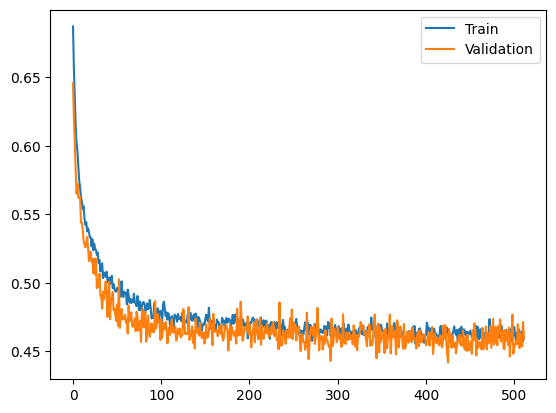

Train points: 512
Val points: 512


In [210]:
import matplotlib.pyplot as plt
train_loss = model.loss_history
val_loss = model.val_loss_history
x = np.arange(0, len(val_loss))

plt.plot(train_loss, label='Train')
plt.plot(val_loss, label='Validation')
plt.legend()
plt.show()
print(f"Train points: {len(train_loss)}")  # должно быть = эпохам
print(f"Val points: {len(val_loss)}")      # должно быть = эпохам (если есть валидация)

In [211]:
y_pred = model.predict(X_test_scaled, threshold = 0.5).squeeze(1).numpy()
y_test = np.array(y_test)
print(f"Accuracy: {acc(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
# Accuracy: 0.8285
# Precision: 0.5656
# Recall: 0.6781
# F1: 0.6168

Accuracy: 0.7760
Precision: 0.4697
Recall: 0.7813
F1: 0.5867


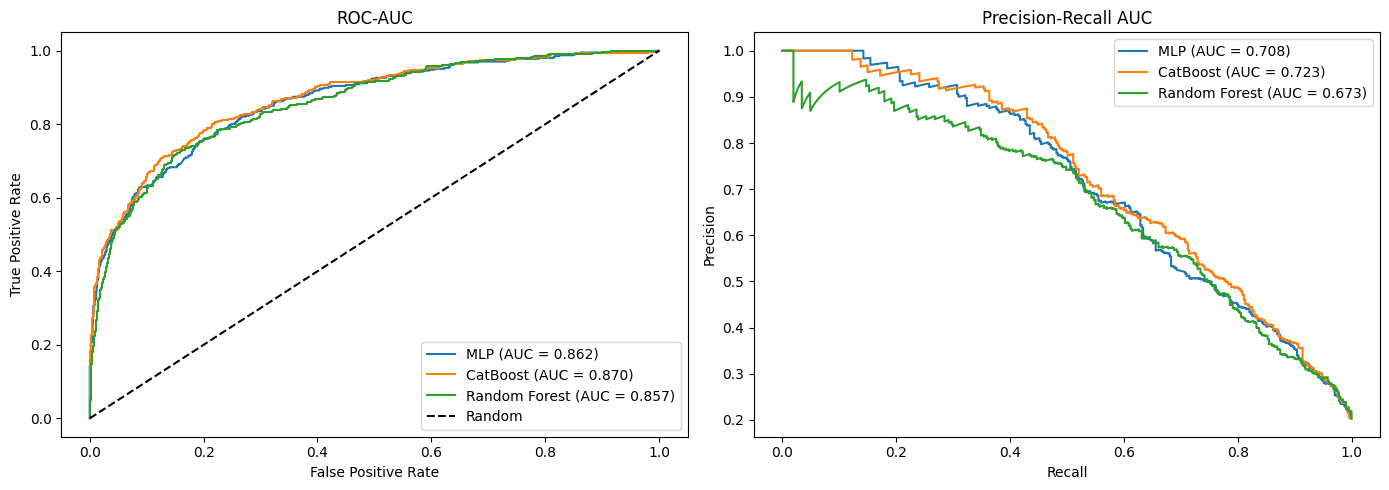

=== ROC-AUC ===
MLP: 0.8621
CatBoost: 0.8703
Random Forest: 0.8569

=== PR-AUC ===
MLP: 0.7083
CatBoost: 0.7226
Random Forest: 0.6734


In [212]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Функция для расчёта и построения
def plot_curves(y_test, probs, model_name, ax_roc, ax_pr):
    # ROC-AUC
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    ax_pr.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.3f})')

# Получаем вероятности для каждой модели
probs_mlp = model.predict_proba(X_test_scaled).flatten()
probs_cat = model_gb.predict_proba(X_test_np)[:, 1]
probs_rf = model_rf.predict_proba(X_test_np)[:, 1]

# Строим графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_curves(y_test_np, probs_mlp, 'MLP', ax1, ax2)
plot_curves(y_test_np, probs_cat, 'CatBoost', ax1, ax2)
plot_curves(y_test_np, probs_rf, 'Random Forest', ax1, ax2)

# Оформление ROC
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC-AUC')
ax1.legend()

# Оформление PR
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall AUC')
ax2.legend()

plt.tight_layout()
plt.show()

# Вывод численных значений
print("=== ROC-AUC ===")
print(f"MLP: {roc_auc_score(y_test_np, probs_mlp):.4f}")
print(f"CatBoost: {roc_auc_score(y_test_np, probs_cat):.4f}")
print(f"Random Forest: {roc_auc_score(y_test_np, probs_rf):.4f}")

print("\n=== PR-AUC ===")
print(f"MLP: {average_precision_score(y_test_np, probs_mlp):.4f}")
print(f"CatBoost: {average_precision_score(y_test_np, probs_cat):.4f}")
print(f"Random Forest: {average_precision_score(y_test_np, probs_rf):.4f}")